In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
path = "Resultados_ICFES_Cordoba_clean.csv"
df = pd.read_csv(path, encoding="utf-8-sig",low_memory=False)
df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    format="%Y-%m-%d",
    errors="coerce"
)

print(df.dtypes)
df["estu_fechanacimiento"]




periodo                                   int64
estu_tipodocumento                          str
estu_consecutivo                            str
cole_area_ubicacion                         str
cole_bilingue                               str
cole_calendario                             str
cole_caracter                               str
cole_cod_dane_establecimiento           float64
cole_cod_dane_sede                        int64
cole_cod_depto_ubicacion                  int64
cole_cod_mcpio_ubicacion                  int64
cole_codigo_icfes                       float64
cole_depto_ubicacion                        str
cole_genero                                 str
cole_jornada                                str
cole_mcpio_ubicacion                        str
cole_naturaleza                             str
cole_nombre_establecimiento                 str
cole_nombre_sede                            str
cole_sede_principal                         str
estu_cod_depto_presentacion             

0        2005-06-05
1        2006-07-25
2        2005-05-13
3        2005-11-09
4        2006-05-26
            ...    
194254   1994-05-17
194255   1996-01-05
194256   1993-12-06
194257   1997-02-16
194258   1992-10-06
Name: estu_fechanacimiento, Length: 194259, dtype: datetime64[us]

In [4]:
df["estu_fechanacimiento"].isna().sum()

np.int64(55)

In [5]:
df["periodo"].isna().sum()

np.int64(0)

In [6]:
df = df.dropna(subset=["estu_fechanacimiento"])
df = df.dropna(subset=["punt_global"])


In [7]:
df.shape

(118512, 51)

In [8]:
# 1. Extract year from periodo
df["anio_prueba"] = df["periodo"] // 10

# 2. Estimated test date: March 15 of that year
df["fecha_est"] = pd.to_datetime(
    df["anio_prueba"].astype(str) + "-03-15",
    format="%Y-%m-%d",
    errors="coerce"
)

# 3. Approximate age at test
df["edad"] = (
    (df["fecha_est"] - df["estu_fechanacimiento"])
    .dt.days / 365.25
).astype(float)

In [9]:
df["edad"].describe()

count    118512.000000
mean         17.078616
std           2.157273
min          -2.494182
25%          16.125941
50%          16.662560
75%          17.593429
max         119.197810
Name: edad, dtype: float64

In [10]:
df.loc[(df['edad'] < 15) | (df['edad'] > 100), 'edad'] = np.nan
df = df.dropna(subset=['edad'])
df["edad"].describe()

count    117050.000000
mean         17.109637
std           1.974092
min          15.000684
25%          16.147844
50%          16.678987
75%          17.607118
max          70.338125
Name: edad, dtype: float64

Text(0.5, 1.0, 'Histograma de Edad de Participantes en el ICFES en Cordoba')

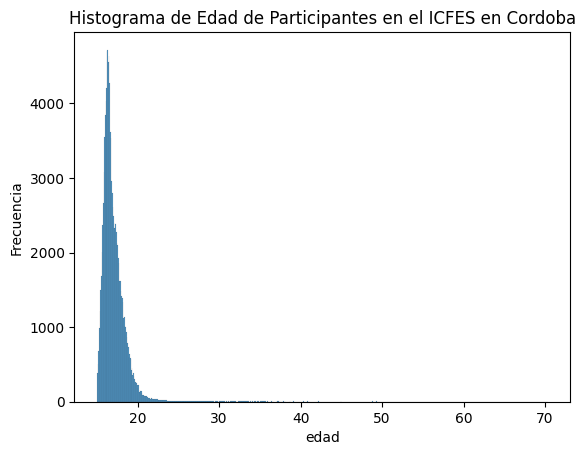

In [22]:
plt.figure()
sns.histplot(data=df, x="edad")
plt.ylabel("Frecuencia")
plt.title("Histograma de Edad de Participantes en el ICFES en Cordoba")

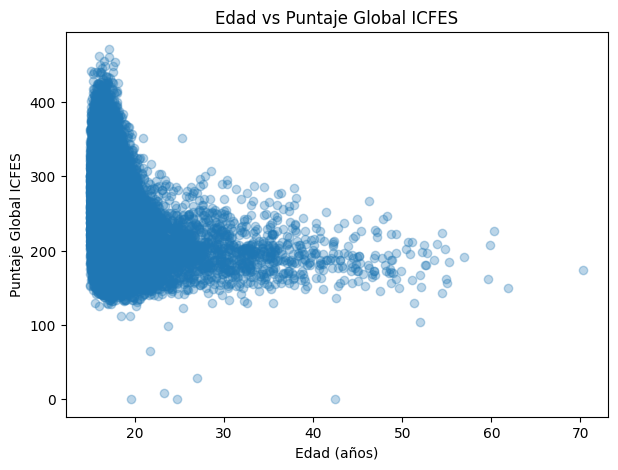

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(df["edad"], df["punt_global"], alpha=0.3)
plt.xlabel("Edad (años)")
plt.ylabel("Puntaje Global ICFES")
plt.title("Edad vs Puntaje Global ICFES")
plt.show()

In [24]:
X = df["edad"]
y = df["punt_global"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

In [25]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            punt_global   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     8396.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:08:52   Log-Likelihood:            -6.1000e+05
No. Observations:              117050   AIC:                         1.220e+06
Df Residuals:                  117048   BIC:                         1.220e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        343.6642      1.131    303.739      0.0

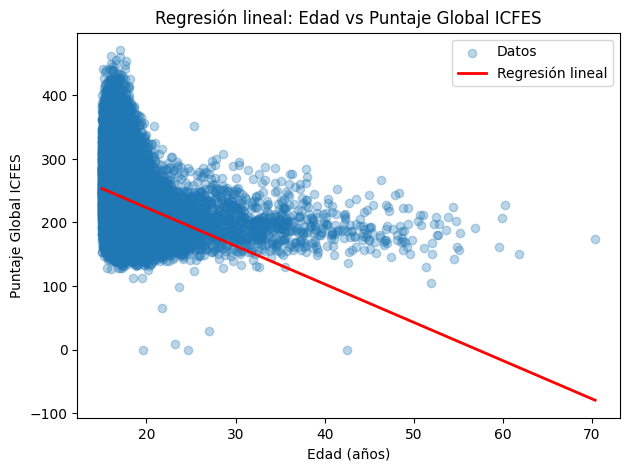

In [26]:
edad_range = np.linspace(df["edad"].min(), df["edad"].max(), 100)
edad_range_const = sm.add_constant(edad_range)
predicted_scores = model.predict(edad_range_const)

plt.figure(figsize=(7, 5))
plt.scatter(df["edad"], df["punt_global"], alpha=0.3, label="Datos")
plt.plot(edad_range, predicted_scores, color="red", linewidth=2, label="Regresión lineal")

plt.xlabel("Edad (años)")
plt.ylabel("Puntaje Global ICFES")
plt.title("Regresión lineal: Edad vs Puntaje Global ICFES")
plt.legend()
plt.show()

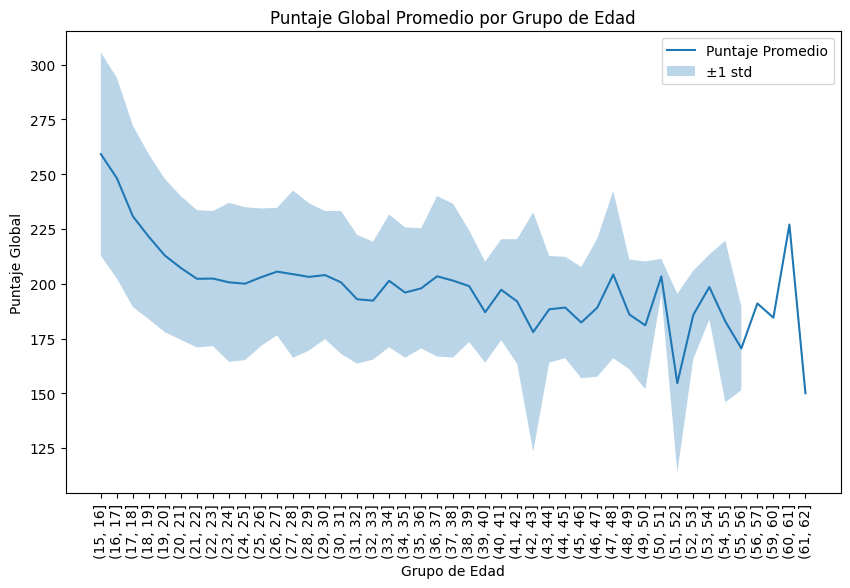

In [27]:
df["edad_bin"] = pd.cut(df["edad"], bins=np.arange(14, 71, 1))

grouped = df.groupby("edad_bin")["punt_global"]

mean = grouped.mean()
std = grouped.std()

plt.figure(figsize=(10,6))
plt.plot(mean.index.astype(str), mean, label="Puntaje Promedio")
plt.fill_between(
    range(len(mean)),
    mean - std,
    mean + std,
    alpha=0.3,
    label="±1 std"
)
plt.xticks(rotation=90)
plt.legend()
plt.xlabel("Grupo de Edad")
plt.ylabel("Puntaje Global")
plt.title("Puntaje Global Promedio por Grupo de Edad")
plt.show()

In [28]:
df["edad_grupo"] = pd.cut(
    df["edad"],
    bins=[15, 18, 22, 30, 100],
    labels=[
        "15–18",
        "19–22",
        "23–30",
        "31+"
    ],
    right=True
)

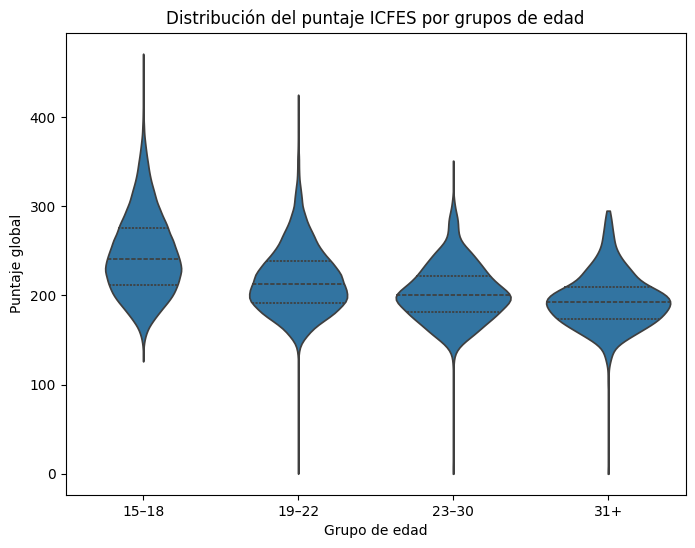

In [29]:
plt.figure(figsize=(8,6))
sns.violinplot(
    x="edad_grupo",
    y="punt_global",
    data=df,
    cut=0,
    inner="quartile"
)

plt.title("Distribución del puntaje ICFES por grupos de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Puntaje global")
plt.show()